# Project 1 — SVR
## Short-Term Price Movement Prediction (synthetic)

Predicting a synthetic asset's next price based on a volatility index, trading volume, sentiment score, and previous price — a smaller, noisier dataset well-suited to SVR's epsilon-tube robustness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 500
prev_price = np.random.normal(100, 15, n)
volatility_index = np.random.uniform(0, 1, n)
volume = np.random.gamma(3, 1000, n)
sentiment_score = np.random.uniform(-1, 1, n)

next_price = (prev_price + 5*sentiment_score - 3*volatility_index
              + 0.0005*volume + np.random.normal(0, 2, n))

df = pd.DataFrame({'prev_price': prev_price, 'volatility_index': volatility_index,
                    'volume': volume, 'sentiment_score': sentiment_score, 'next_price': next_price})
df.head()


,prev_price,volatility_index,volume,sentiment_score,next_price
0,107.450712,0.645917,2402.967611,-0.205970,105.914647
1,97.926035,0.570778,2913.495707,-0.825814,93.371596
2,109.715328,0.356097,3315.150848,0.234133,108.988631
3,122.845448,0.986515,2074.538650,-0.772323,115.138579
4,96.487699,0.605775,2991.061370,-0.309554,96.279842


## 2. Preprocessing

In [3]:
X = df.drop('next_price', axis=1)
y = df['next_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=10, epsilon=0.5, gamma='scale')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 2.9537563834137126
RMSE: 6.337187501612293
R2 Score: 0.8293605589447081


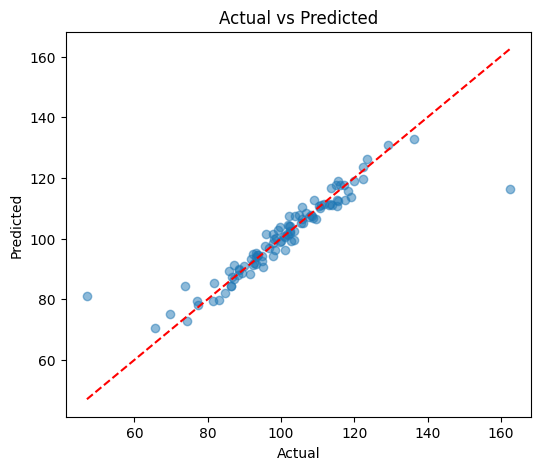

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- prev_price should dominate the relationship (next price is close to previous price plus small adjustments) — check the actual-vs-predicted scatter plot for how tightly points hug the diagonal.
- Try increasing `epsilon` (e.g., to 2.0) and see how many fewer support vectors are used (`len(model.support_)`) as the tolerance widens.
- Next steps: compare `kernel='linear'` vs `'rbf'` — if the true relationship is close to linear (as built here), linear SVR may perform just as well with far less tuning.

---
# Project 2 — Your Turn
**Dataset:** Dots dataset (`seaborn.load_dataset('dots')`) — predict `coherence` (or `firing_rate`) from `time`, `align`, and other columns.

```python
import seaborn as sns
dots = sns.load_dataset('dots')
```
**Tasks:** encode categorical columns, scale features, train SVR, evaluate with MAE/RMSE/R², and try tuning `C`/`epsilon`/`gamma` together via `GridSearchCV`.
